In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('birth defect.csv')

# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df.head()

Saving birth defect.csv to birth defect (1).csv


,geography,datayears,anencephaly,anophthalmia_microphthalmia,anotia_microtia,aortic_valve_stenosis,atrial_septal_defect,atrioventricular_septal_defect__,biliary_atresia,bladder_exstrophy,...,tricuspid_valve_atresia,tricuspid_valve_atresia_and_sten,trisomy_13,trisomy_18,trisomy_21__down_syndrome_,turner_syndrome,ventricular_septal_defect,totalmalebirths,totalfemalebirths,totallivebirths
0,Albany,2000-2002,1,0,0,2,19,3,2,0,...,1,1,1,2,12,1,39,4951,4799,9750
1,Allegany,2000-2002,0,0,0,0,0,1,0,0,...,0,0,0,0,2,0,6,811,799,1610
2,Bronx,2000-2002,1,5,2,4,184,14,5,0,...,1,4,8,8,60,3,192,34858,33306,68165
3,Broome,2000-2002,0,0,0,4,35,1,1,0,...,0,0,0,1,8,0,40,3352,3068,6421
4,Cattaraugus,2000-2002,0,0,1,0,6,0,0,0,...,0,0,0,0,3,0,15,1576,1420,2998


Data Cleaning & Transformation

In [ ]:
# Rename columns to match project requirement
df = df.rename(columns={
    'geography': 'county',
    'datayears': 'year'
})

# Remove missing values
df = df.dropna()


# Convert data types
df['year'] = df['year'].astype(int)
df['births'] = df['births'].astype(int)
df['birth_defects'] = df['birth_defects'].astype(int)

# Create defect rate
df['defect_rate'] = df['birth_defects'] / df['births']


Explanation:
We cleaned the dataset, renamed columns, and created a defect rate to compare counties fairly.

Counties with the Highest rates

In [ ]:
# Sort by defect_rate in descending order and display top counties
top_defect_rate_counties = df.sort_values(by='defect_rate', ascending=False)
display(top_defect_rate_counties[['county', 'year', 'defect_rate']].head(10))

,county,year,defect_rate
250,Bronx,2012,0.024079
130,Chautauqua,2006,0.022233
268,Hamilton,2012,0.021277
287,Putnam,2012,0.020782
188,Bronx,2009,0.018996
254,Chautauqua,2012,0.018944
68,Chautauqua,2003,0.018123
192,Chautauqua,2009,0.018022
291,Rockland,2012,0.017901
229,Rockland,2009,0.017484


Trend Over Time

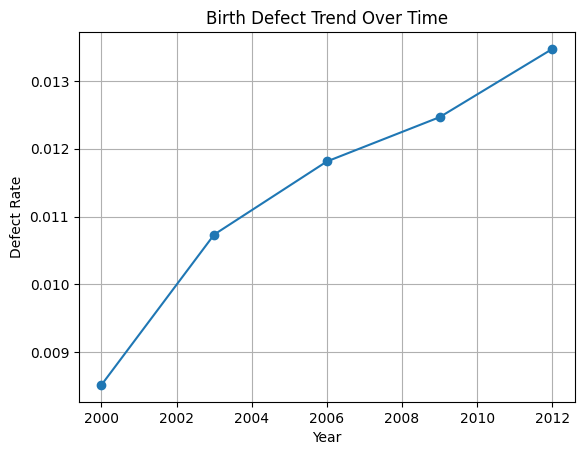

In [ ]:
trend = analyze_defect_rates(df, 'year')

plt.figure()
plt.plot(trend['year'], trend['defect_rate'], marker='o')
plt.title("Birth Defect Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Defect Rate")
plt.grid()
plt.show()

County Analysis

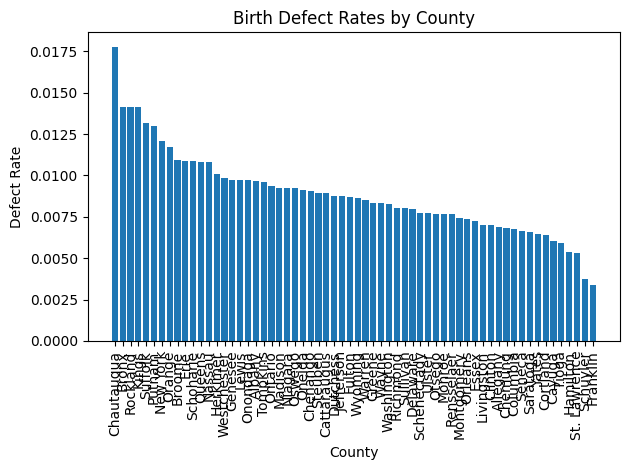

(        county  births  birth_defects  defect_rate
 6   Chautauqua   21449            381     0.017763
 2        Bronx  334169           4730     0.014155
 43    Rockland   68199            965     0.014150
 23       Kings  612099           8639     0.014114
 51     Suffolk  270738           3569     0.013182,
           county  births  birth_defects  defect_rate
 53         Tioga    7260             43     0.005923
 20      Hamilton     557              3     0.005386
 49  St. Lawrence   18298             97     0.005301
 47      Schuyler    2674             10     0.003740
 16      Franklin    7368             25     0.003393)

In [ ]:
county = analyze_defect_rates(df, 'county')

# sort highest to lowest
county = county.sort_values(by='defect_rate', ascending=False)

plt.figure()
plt.bar(county['county'], county['defect_rate'])
plt.xticks(rotation=90)
plt.title("Birth Defect Rates by County")
plt.xlabel("County")
plt.ylabel("Defect Rate")
plt.tight_layout()
plt.show()

county.head(), county.tail()

Highest and Lowest

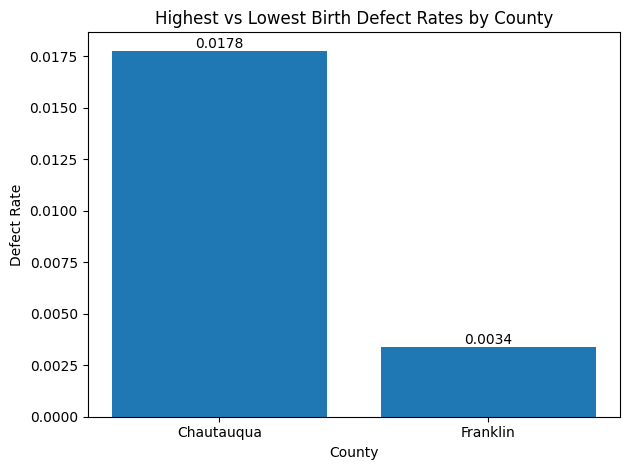

In [ ]:
import pandas as pd

plt.figure()

top_bottom = pd.DataFrame([highest, lowest])
bars = plt.bar(top_bottom['county'], top_bottom['defect_rate'])

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval,4),
             ha='center', va='bottom')

plt.title("Highest vs Lowest Birth Defect Rates by County")
plt.xlabel("County")
plt.ylabel("Defect Rate")

plt.tight_layout()
plt.show()

Highest vs Lowest County

In [ ]:
highest = county.iloc[0]
lowest = county.iloc[-1]

print("Highest County:\n", highest)
print("\nLowest County:\n", lowest)

Highest County:
 county           Chautauqua
births                21449
birth_defects           381
defect_rate        0.017763
Name: 6, dtype: object

Lowest County:
 county           Franklin
births               7368
birth_defects          25
defect_rate      0.003393
Name: 16, dtype: object


Regression

In [ ]:
df['county_code'] = df['county'].astype('category').cat.codes

X = sm.add_constant(df['county_code'])
y = df['defect_rate']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            defect_rate   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.318
Date:                Tue, 21 Apr 2026   Prob (F-statistic):              0.252
Time:                        00:25:41   Log-Likelihood:                 1295.3
No. Observations:                 310   AIC:                            -2587.
Df Residuals:                     308   BIC:                            -2579.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0093      0.000     22.307      

Hypothesis Testing (ANOVA)

In [ ]:
groups = [g['defect_rate'].values for n,g in df.groupby('county')]
stats.f_oneway(*groups)

F_onewayResult(statistic=np.float64(3.7256171134471803), pvalue=np.float64(1.5211402281025074e-13))

Combined Regression + ANOVA Function

In [ ]:
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.pyplot as plt

def full_stat_analysis(df, x_col, y_col, group_col=None, plot=True):
    """
    Performs regression + ANOVA + optional plot

    Parameters:
    df (DataFrame)
    x_col (str): numeric independent variable (e.g., 'year' or encoded county)
    y_col (str): dependent variable (e.g., 'defect_rate')
    group_col (str): categorical variable for ANOVA (e.g., 'county')
    plot (bool): whether to show regression plot

    Returns:
    dict with regression + ANOVA results
    """

    results = {}

    # Clean data
    data = df[[x_col, y_col]].dropna()

    # -------- REGRESSION --------
    X = sm.add_constant(data[x_col])
    y = data[y_col]

    model = sm.OLS(y, X).fit()

    print("\n📈 REGRESSION RESULTS")
    print(model.summary())

    results['regression_model'] = model

    # -------- ANOVA --------
    if group_col:
        groups = [g[y_col].values for _, g in df.groupby(group_col)]

        f_stat, p_val = stats.f_oneway(*groups)

        print("\n🧪 ANOVA RESULTS")
        print("F-statistic:", f_stat)
        print("p-value:", p_val)

        results['anova'] = {
            'f_stat': f_stat,
            'p_value': p_val
        }

    # -------- PLOT --------
    if plot:
        plt.figure()
        plt.scatter(data[x_col], data[y_col])

        y_pred = model.predict(X)
        plt.plot(data[x_col], y_pred)

        plt.title(f"Regression: {x_col} vs {y_col}")
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.tight_layout()
        plt.show()

    return results


📈 REGRESSION RESULTS
                            OLS Regression Results                            
Dep. Variable:            defect_rate   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.318
Date:                Tue, 21 Apr 2026   Prob (F-statistic):              0.252
Time:                        04:22:15   Log-Likelihood:                 1295.3
No. Observations:                 310   AIC:                            -2587.
Df Residuals:                     308   BIC:                            -2579.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0093      

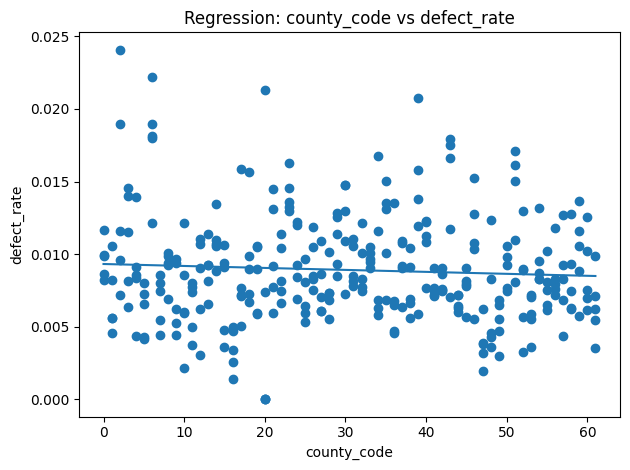

In [ ]:
# Convert county to numeric
df['county_code'] = df['county'].astype('category').cat.codes

results = full_stat_analysis(
    df,
    x_col='county_code',
    y_col='defect_rate',
    group_col='county'
)


📈 REGRESSION RESULTS
                            OLS Regression Results                            
Dep. Variable:            defect_rate   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     20.54
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           8.37e-06
Time:                        04:25:18   Log-Likelihood:                 1304.6
No. Observations:                 310   AIC:                            -2605.
Df Residuals:                     308   BIC:                            -2598.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4304      0.0

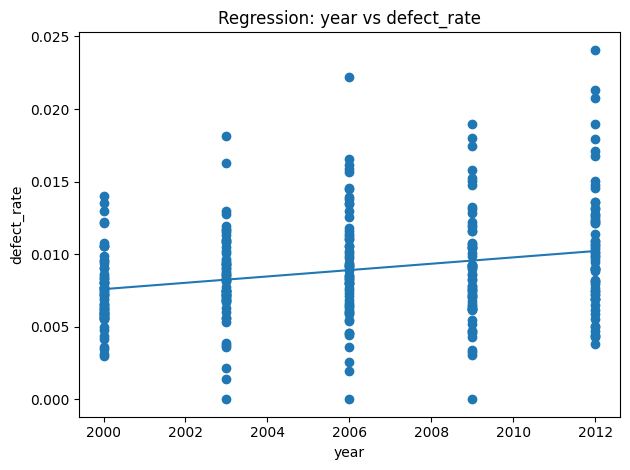

In [ ]:
results = full_stat_analysis(
    df,
    x_col='year',
    y_col='defect_rate'
)